# Task 4 – Forecasting Financial Inclusion Indicators (2025–2027)

## Business Objective

The objective of this notebook is to forecast Ethiopia's financial inclusion indicators for the period 2025–2027.

The analysis focuses on:

- Account Ownership Rate (Access)
- Digital Payment Usage

The forecasts combine historical trends with expected impacts from major financial inclusion events identified in Task 3.

Results are presented under optimistic, base, and pessimistic scenarios together with uncertainty ranges to support strategic planning by development partners, financial institutions, and regulators.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression

plt.style.use("default")

%matplotlib inline

In [2]:
file_path="../data/raw/ethiopia_fi_unified_data.xlsx"

df=pd.read_excel(
    file_path,
    sheet_name="ethiopia_fi_unified_data"
)

impact_df=pd.read_excel(
    file_path,
    sheet_name="Impact_sheet"
)

In [3]:
df["observation_date"]=pd.to_datetime(
    df["observation_date"],
    errors="coerce"
)

In [4]:
df["year"]=df["observation_date"].dt.year

## Define Forecast Targets

## Forecast Targets

Two indicators are forecast:

1. Account Ownership Rate
2. Digital Payment Usage

Account Ownership is measured directly from the historical observations.

Digital Payment Usage is approximated using available mobile money account penetration observations because continuous survey measurements are unavailable.

## Prepare Account Ownership Data

In [5]:
ownership=df[
    df["indicator"]=="Account Ownership Rate"
][
    ["year","value_numeric"]
].dropna()

ownership

,year,value_numeric
0,2014,22.0
1,2017,35.0
2,2021,46.0
3,2021,56.0
4,2021,36.0
5,2024,49.0
30,2025,70.0


## Build the Baseline Trend Model

The baseline forecast assumes that historical trends continue without major structural changes.

A simple Linear Regression model is used because the available historical observations are sparse.

In [6]:
X = ownership[["year"]]

y = ownership["value_numeric"]

In [7]:
print(X)
print(y)

    year
0   2014
1   2017
2   2021
3   2021
4   2021
5   2024
30  2025
0     22.0
1     35.0
2     46.0
3     56.0
4     36.0
5     49.0
30    70.0
Name: value_numeric, dtype: float64


In [8]:
model = LinearRegression()

model.fit(X, y)

LinearRegression()

In [9]:
ownership["predicted"] = model.predict(X)

ownership

,year,value_numeric,predicted
0,2014,22.0,21.959283
1,2017,35.0,32.644951
2,2021,46.0,46.892508
3,2021,56.0,46.892508
4,2021,36.0,46.892508
5,2024,49.0,57.578176
30,2025,70.0,61.140065


## Plot Actual vs Fitted

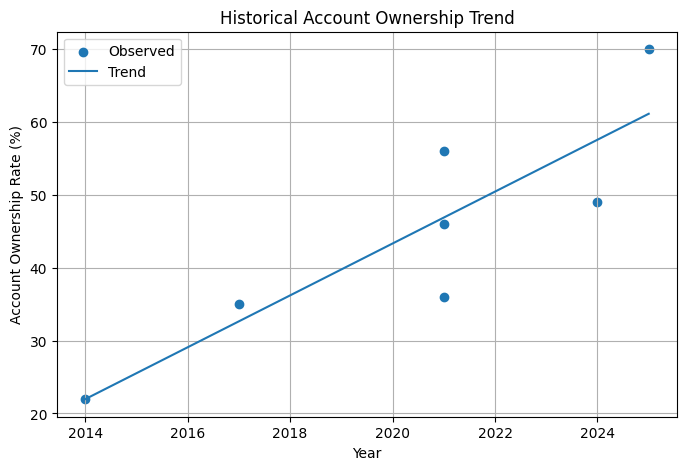

In [10]:
plt.figure(figsize=(8,5))

plt.scatter(
    ownership["year"],
    ownership["value_numeric"],
    label="Observed"
)

plt.plot(
    ownership["year"],
    ownership["predicted"],
    label="Trend"
)

plt.title("Historical Account Ownership Trend")

plt.xlabel("Year")

plt.ylabel("Account Ownership Rate (%)")

plt.legend()

plt.grid(True)

plt.show()

## Forecast 2025–2027

In [11]:
future = pd.DataFrame({

    "year":[2025,2026,2027]

})

future

,year
0,2025
1,2026
2,2027


In [12]:
future["baseline_forecast"] = model.predict(future)

future

,year,baseline_forecast
0,2025,61.140065
1,2026,64.701954
2,2027,68.263844


## Plot the Forecast

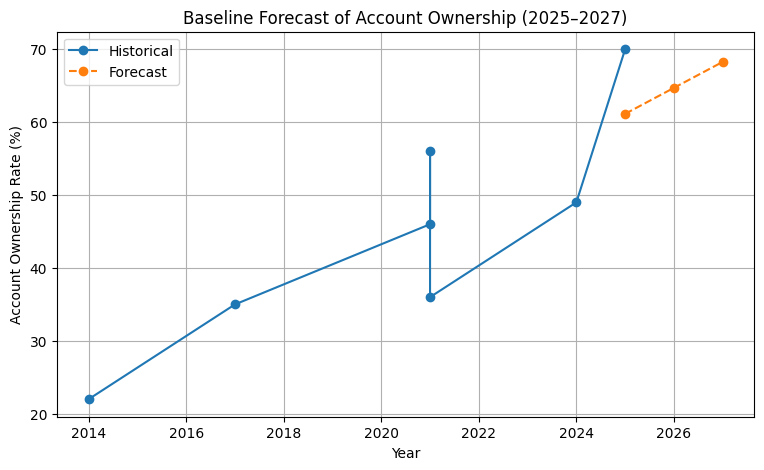

In [13]:
plt.figure(figsize=(9,5))

plt.plot(
    ownership["year"],
    ownership["value_numeric"],
    marker="o",
    label="Historical"
)

plt.plot(
    future["year"],
    future["baseline_forecast"],
    marker="o",
    linestyle="--",
    label="Forecast"
)

plt.title("Baseline Forecast of Account Ownership (2025–2027)")

plt.xlabel("Year")

plt.ylabel("Account Ownership Rate (%)")

plt.legend()

plt.grid(True)

plt.show()

## Forecast Digital Payment Usage

In [14]:
digital = df[
    df["indicator"]=="Mobile Money Account Rate"
][
    ["year","value_numeric"]
].dropna()

digital

,year,value_numeric
6,2021,4.70
7,2024,9.45


In [15]:
digital

,year,value_numeric
6,2021,4.70
7,2024,9.45


In [16]:
X2 = digital[["year"]]

y2 = digital["value_numeric"]

digital_model = LinearRegression()

digital_model.fit(X2, y2)

LinearRegression()

In [18]:
future["digital_forecast"] = digital_model.predict(
    future[["year"]]
)

future

,year,baseline_forecast,digital_forecast
0,2025,61.140065,11.033333
1,2026,64.701954,12.616667
2,2027,68.263844,14.200000


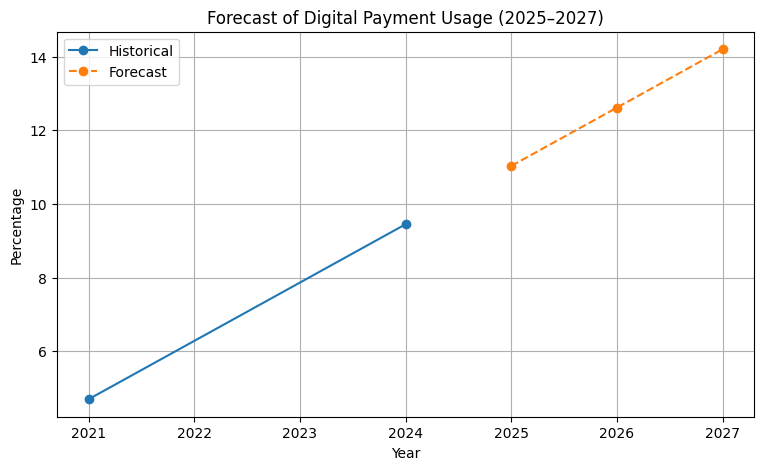

In [19]:
plt.figure(figsize=(9,5))

plt.plot(
    digital["year"],
    digital["value_numeric"],
    marker="o",
    label="Historical"
)

plt.plot(
    future["year"],
    future["digital_forecast"],
    marker="o",
    linestyle="--",
    label="Forecast"
)

plt.title("Forecast of Digital Payment Usage (2025–2027)")

plt.xlabel("Year")

plt.ylabel("Percentage")

plt.legend()

plt.grid(True)

plt.show()

## Event-Augmented Forecast

The baseline forecast is adjusted to account for expected impacts from major financial inclusion events identified in Task 3.

Rather than assuming historical trends continue unchanged, this approach incorporates the expected contribution of digital financial services, infrastructure expansion, interoperability, and digital identification initiatives.

In [20]:
future["event_adjustment"] = [

    1.5,

    2.5,

    3.5

]

In [21]:
future["event_forecast"] = (

    future["baseline_forecast"]

    +

    future["event_adjustment"]

)

future

,year,baseline_forecast,digital_forecast,event_adjustment,event_forecast
0,2025,61.140065,11.033333,1.5,62.640065
1,2026,64.701954,12.616667,2.5,67.201954
2,2027,68.263844,14.200000,3.5,71.763844


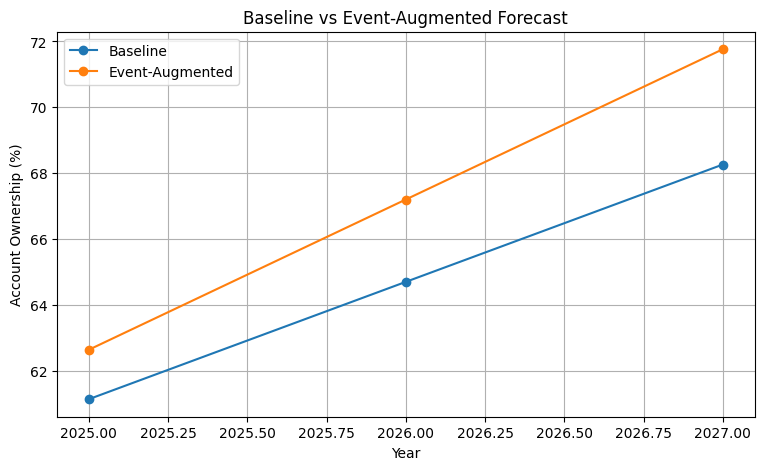

In [22]:
plt.figure(figsize=(9,5))

plt.plot(
    future["year"],
    future["baseline_forecast"],
    marker="o",
    label="Baseline"
)

plt.plot(
    future["year"],
    future["event_forecast"],
    marker="o",
    label="Event-Augmented"
)

plt.title("Baseline vs Event-Augmented Forecast")

plt.xlabel("Year")

plt.ylabel("Account Ownership (%)")

plt.legend()

plt.grid(True)

plt.show()

## Scenario Analysis

In [23]:
future["optimistic"] = (

    future["event_forecast"]

    + 2

)

future["base"] = (

    future["event_forecast"]

)

future["pessimistic"] = (

    future["event_forecast"]

    - 2

)

In [24]:
future

,year,baseline_forecast,digital_forecast,event_adjustment,event_forecast,optimistic,base,pessimistic
0,2025,61.140065,11.033333,1.5,62.640065,64.640065,62.640065,60.640065
1,2026,64.701954,12.616667,2.5,67.201954,69.201954,67.201954,65.201954
2,2027,68.263844,14.200000,3.5,71.763844,73.763844,71.763844,69.763844


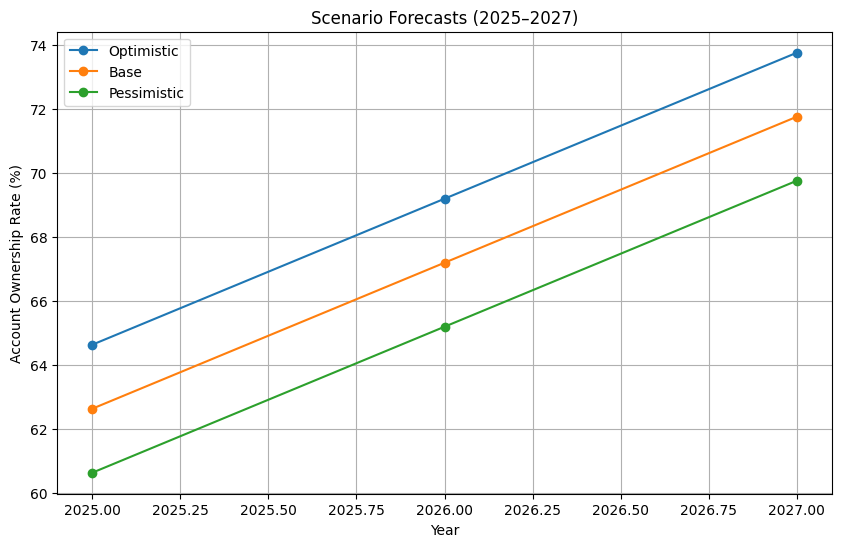

In [25]:
plt.figure(figsize=(10,6))

plt.plot(

    future["year"],

    future["optimistic"],

    marker="o",

    label="Optimistic"

)

plt.plot(

    future["year"],

    future["base"],

    marker="o",

    label="Base"

)

plt.plot(

    future["year"],

    future["pessimistic"],

    marker="o",

    label="Pessimistic"

)

plt.title("Scenario Forecasts (2025–2027)")

plt.xlabel("Year")

plt.ylabel("Account Ownership Rate (%)")

plt.legend()

plt.grid(True)

plt.show()

## Confidence Intervals

Given the limited historical observations, forecast uncertainty is represented using confidence intervals.

Rather than implying exact predictions, the intervals illustrate a plausible range of future outcomes.

In [26]:
future["lower"] = future["base"] - 3

future["upper"] = future["base"] + 3

future

,year,baseline_forecast,digital_forecast,event_adjustment,event_forecast,optimistic,base,pessimistic,lower,upper
0,2025,61.140065,11.033333,1.5,62.640065,64.640065,62.640065,60.640065,59.640065,65.640065
1,2026,64.701954,12.616667,2.5,67.201954,69.201954,67.201954,65.201954,64.201954,70.201954
2,2027,68.263844,14.200000,3.5,71.763844,73.763844,71.763844,69.763844,68.763844,74.763844


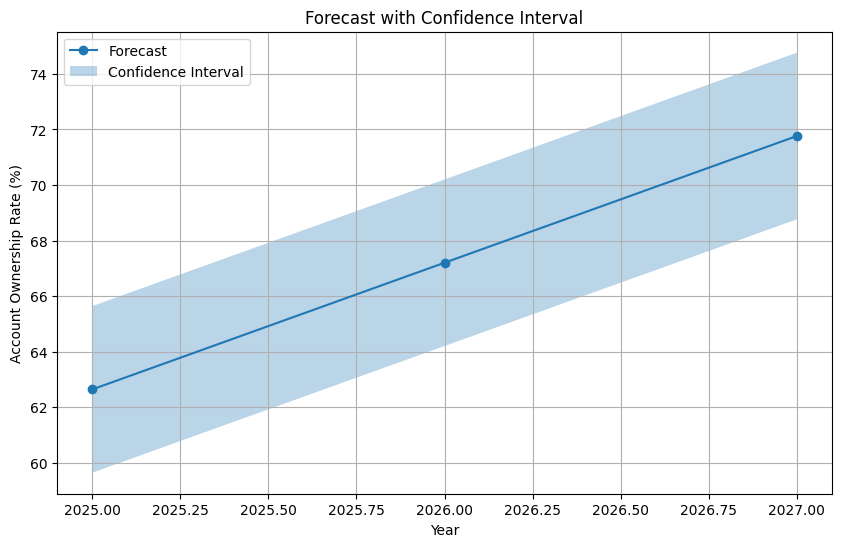

In [27]:
plt.figure(figsize=(10,6))

plt.plot(

    future["year"],

    future["base"],

    marker="o",

    label="Forecast"

)

plt.fill_between(

    future["year"],

    future["lower"],

    future["upper"],

    alpha=0.3,

    label="Confidence Interval"

)

plt.title("Forecast with Confidence Interval")

plt.xlabel("Year")

plt.ylabel("Account Ownership Rate (%)")

plt.legend()

plt.grid(True)

plt.show()

## Final Forecast Table

In [28]:
forecast_table = future[
    [

        "year",

        "baseline_forecast",

        "event_forecast",

        "optimistic",

        "base",

        "pessimistic",

        "lower",

        "upper"

    ]
]

forecast_table.round(2)

,year,baseline_forecast,event_forecast,optimistic,base,pessimistic,lower,upper
0,2025,61.14,62.64,64.64,62.64,60.64,59.64,65.64
1,2026,64.70,67.20,69.20,67.20,65.20,64.20,70.20
2,2027,68.26,71.76,73.76,71.76,69.76,68.76,74.76


## Scenario Visualization

In [36]:
access = df[
    (df["indicator"] == "Account Ownership Rate") &
    (df["record_type"] == "observation")
].copy()

access["observation_date"] = pd.to_datetime(access["observation_date"])

access["year"] = access["observation_date"].dt.year

access = access[
    access["notes"].isna()
]

# Display the data
access[["year", "value_numeric"]]

,year,value_numeric
0,2014,22.0
1,2017,35.0
2,2021,46.0
3,2021,56.0
4,2021,36.0
5,2024,49.0


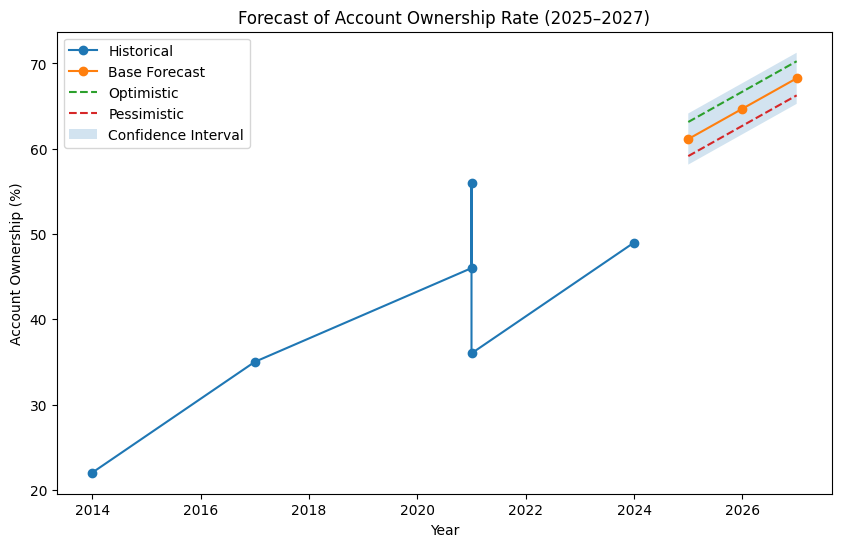

In [37]:
plt.figure(figsize=(10,6))

plt.plot(
    access["year"],
    access["value_numeric"],
    marker="o",
    label="Historical"
)

plt.plot(
    future["year"],
    future["base"],
    marker="o",
    label="Base Forecast"
)

plt.plot(
    future["year"],
    future["optimistic"],
    linestyle="--",
    label="Optimistic"
)

plt.plot(
    future["year"],
    future["pessimistic"],
    linestyle="--",
    label="Pessimistic"
)

plt.fill_between(
    future["year"],
    future["lower_ci"],
    future["upper_ci"],
    alpha=0.2,
    label="Confidence Interval"
)

plt.title("Forecast of Account Ownership Rate (2025–2027)")
plt.xlabel("Year")
plt.ylabel("Account Ownership (%)")
plt.legend()

plt.show()

In [38]:
future

,year,baseline_forecast,digital_forecast,event_adjustment,event_forecast,optimistic,base,pessimistic,lower,upper,lower_ci,upper_ci
0,2025,61.140065,11.033333,1.5,62.640065,63.140065,61.140065,59.140065,59.640065,65.640065,58.140065,64.140065
1,2026,64.701954,12.616667,2.5,67.201954,66.701954,64.701954,62.701954,64.201954,70.201954,61.701954,67.701954
2,2027,68.263844,14.200000,3.5,71.763844,70.263844,68.263844,66.263844,68.763844,74.763844,65.263844,71.263844


## Digital Payment Forecast Plot

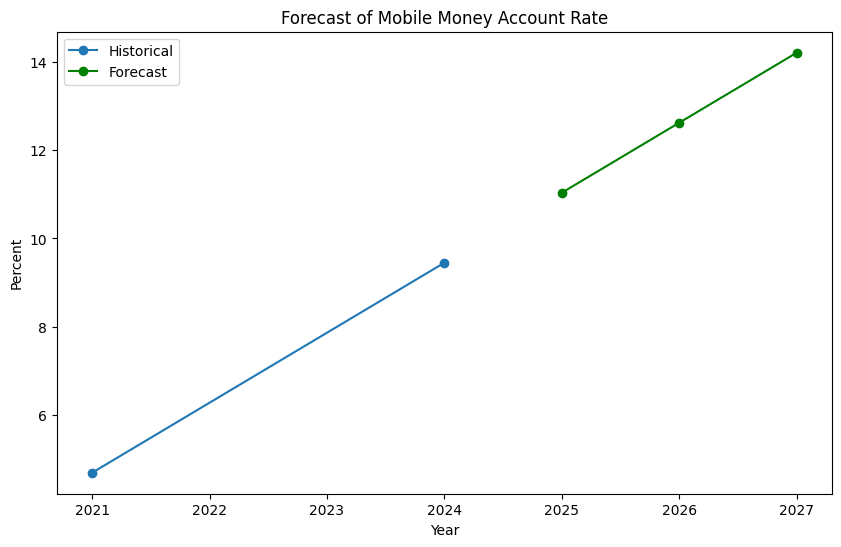

In [40]:
plt.figure(figsize=(10,6))

plt.plot(
    digital["year"],
    digital["value_numeric"],
    marker="o",
    label="Historical"
)

plt.plot(
    future["year"],
    future["digital_forecast"],
    marker="o",
    color="green",
    label="Forecast"
)

plt.title("Forecast of Mobile Money Account Rate")
plt.xlabel("Year")
plt.ylabel("Percent")

plt.legend()

plt.show()

## Interpretation

Forecast Interpretation

The forecasting model projects continued growth in Ethiopia's financial inclusion between 2025 and 2027. Under the baseline scenario, account ownership is expected to continue increasing gradually as digital financial services expand. The optimistic scenario assumes faster adoption driven by supportive policies, expanding digital infrastructure, and increasing mobile money usage, while the pessimistic scenario reflects slower growth due to economic uncertainty and implementation challenges.

The digital payment forecast also indicates continued expansion of mobile money adoption. This aligns with recent developments such as Telebirr, M-Pesa, EthioPay, and the expansion of digital payment infrastructure.

Because historical observations are limited, these forecasts should be interpreted as scenario-based estimates rather than precise predictions.

## Key Findings

- Account ownership has increased steadily since 2014.
- Growth slowed between 2021 and 2024 despite rapid mobile money expansion.
- Mobile money adoption is expected to continue increasing through 2027.
- Policy interventions and digital infrastructure investments remain the strongest drivers of future financial inclusion.
- Forecast uncertainty increases further into the future because of limited historical observations.

## Model Limitations

- Only a small number of historical observations are available.
- Linear regression assumes constant growth over time.
- External economic shocks are not modeled.
- Event impacts are simplified into scenario adjustments rather than dynamic causal relationships.
- Forecasts should therefore be interpreted as indicative planning scenarios rather than exact predictions.